# Лабораторная работа №4

---
## Импорты

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import seaborn as sns
%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


---
## Подготовка данных DVM

In [2]:
DATA_DIR = 'DATA/DVM'

classes = sorted(os.listdir(os.path.join(DATA_DIR, 'train')))
for cls in classes:
    n = len(os.listdir(os.path.join(DATA_DIR, 'train', cls)))
    print(f'  {cls}: {n} train images')
print(f'\nВсего классов: {len(classes)}')

  Beige: 480 train images
  Black: 640 train images
  Blue: 640 train images
  Bronze: 263 train images
  Brown: 640 train images
  Gold: 173 train images
  Green: 621 train images
  Grey: 640 train images
  Multicolour: 156 train images
  Orange: 447 train images
  Pink: 69 train images
  Purple: 289 train images
  Red: 640 train images
  Silver: 640 train images
  White: 640 train images
  Yellow: 533 train images

Всего классов: 16


### Датасет и DataLoader

Train: 7511, Test: 1883
Классы (16): ['Beige', 'Black', 'Blue', 'Bronze', 'Brown', 'Gold', 'Green', 'Grey', 'Multicolour', 'Orange', 'Pink', 'Purple', 'Red', 'Silver', 'White', 'Yellow']


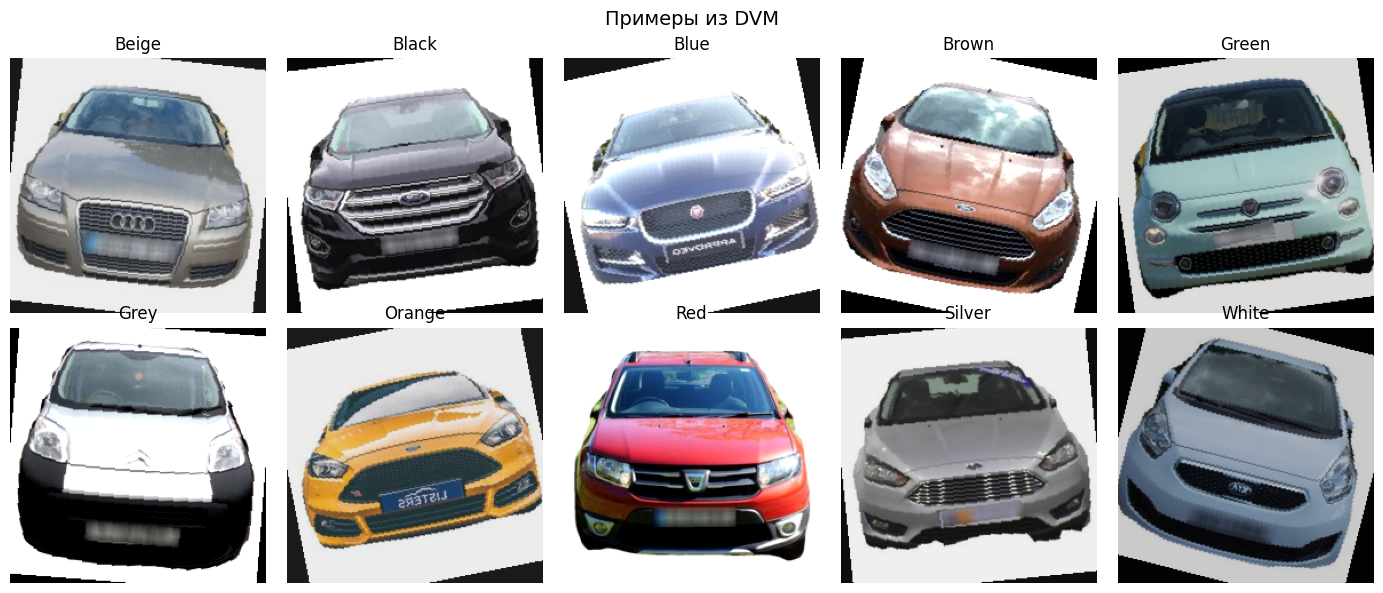

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=train_transform)
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f'Train: {len(train_dataset)}, Test: {len(test_dataset)}')
print(f'Классы ({num_classes}): {class_names}')

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i * (len(train_dataset) // 10)]
    img_show = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img_show)
    ax.set_title(class_names[label])
    ax.axis('off')
plt.suptitle('Примеры из DVM', fontsize=14)
plt.tight_layout()
plt.show()

---
## Общие функции обучения и оценки

In [4]:
def train_model(model, train_loader, test_loader, epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        # Train
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            t_loss += loss.item() * images.size(0)
            t_correct += (outputs.argmax(1) == labels).sum().item()
            t_total += images.size(0)

        history['train_loss'].append(t_loss / t_total)
        history['train_acc'].append(t_correct / t_total)

        # Test
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                v_loss += loss.item() * images.size(0)
                v_correct += (outputs.argmax(1) == labels).sum().item()
                v_total += images.size(0)

        history['test_loss'].append(v_loss / v_total)
        history['test_acc'].append(v_correct / v_total)
        scheduler.step()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch {epoch+1:2d}/{epochs} | '
                  f'Train loss: {history["train_loss"][-1]:.4f}, acc: {history["train_acc"][-1]:.4f} | '
                  f'Test  loss: {history["test_loss"][-1]:.4f}, acc: {history["test_acc"][-1]:.4f}')

    return history


def evaluate_f1(model, test_loader, class_names):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            preds = model(images).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f'F1_macro: {f1:.4f}')
    print()
    print(classification_report(all_labels, all_preds, target_names=class_names))
    return f1, np.array(all_labels), np.array(all_preds)


def plot_history(histories, labels):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for h, label in zip(histories, labels):
        epochs = range(1, len(h['train_loss']) + 1)
        axes[0].plot(epochs, h['train_loss'], '--', label=f'{label} train')
        axes[0].plot(epochs, h['test_loss'], '-', label=f'{label} test')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True)

    for h, label in zip(histories, labels):
        epochs = range(1, len(h['train_acc']) + 1)
        axes[1].plot(epochs, h['train_acc'], '--', label=f'{label} train')
        axes[1].plot(epochs, h['test_acc'], '-', label=f'{label} test')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

print('Функции обучения и оценки определены.')

Функции обучения и оценки определены.


---
## Модель 1: ResNet18 (предобучена на ImageNet)

In [5]:
import torchvision.models as models

resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in resnet.parameters():
    param.requires_grad = False

resnet.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(resnet.fc.in_features, num_classes)
)

for param in resnet.layer4.parameters():
    param.requires_grad = True
for param in resnet.fc.parameters():
    param.requires_grad = True

resnet = resnet.to(device)

trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet.parameters())
print(f'ResNet18: {total:,} всего параметров, {trainable:,} обучаемых')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\valer/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:05<00:00, 8.54MB/s]


ResNet18: 11,184,720 всего параметров, 8,401,936 обучаемых


=== Обучение ResNet18 (ImageNet) ===
Epoch  1/15 | Train loss: 1.3431, acc: 0.5807 | Test  loss: 1.1628, acc: 0.6357
Epoch  5/15 | Train loss: 0.6740, acc: 0.7831 | Test  loss: 0.9416, acc: 0.7063
Epoch 10/15 | Train loss: 0.2439, acc: 0.9185 | Test  loss: 0.9872, acc: 0.7467
Epoch 15/15 | Train loss: 0.0845, acc: 0.9716 | Test  loss: 1.1140, acc: 0.7477


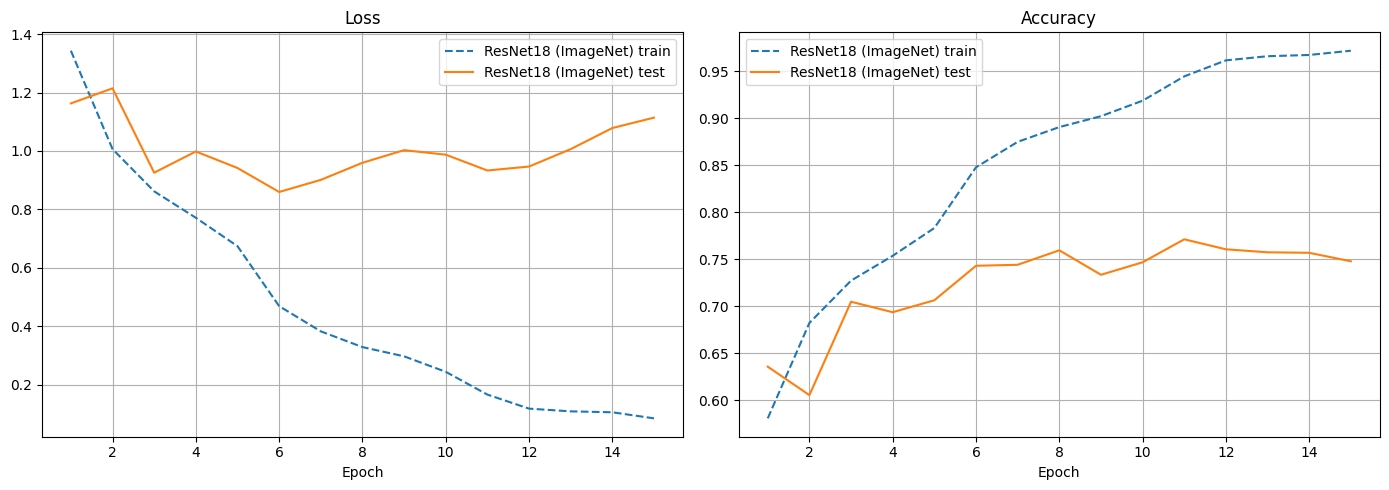

In [6]:
print('=== Обучение ResNet18 (ImageNet) ===')
history_resnet = train_model(resnet, train_loader, test_loader, epochs=15, lr=1e-3)
plot_history([history_resnet], ['ResNet18 (ImageNet)'])

In [8]:
print('=== Оценка ResNet18 ===')
f1_resnet, _, _ = evaluate_f1(resnet, test_loader, class_names)

=== Оценка ResNet18 ===
F1_macro: 0.7306

              precision    recall  f1-score   support

       Beige       0.81      0.68      0.74       120
       Black       0.68      0.59      0.64       160
        Blue       0.83      0.71      0.77       160
      Bronze       0.38      0.58      0.46        66
       Brown       0.60      0.62      0.61       160
        Gold       0.63      0.39      0.48        44
       Green       0.68      0.83      0.74       156
        Grey       0.62      0.63      0.63       160
 Multicolour       0.56      0.47      0.51        40
      Orange       0.87      0.82      0.84       112
        Pink       0.89      0.94      0.92        18
      Purple       0.82      0.85      0.83        73
         Red       0.89      0.94      0.92       160
      Silver       0.75      0.82      0.79       160
       White       0.91      0.84      0.87       160
      Yellow       0.96      0.95      0.95       134

    accuracy                          

---
## Модель 2: ViT-Tiny (предобучена на ImageNet-21k)

In [ ]:
vit = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=num_classes)

for param in vit.parameters():
    param.requires_grad = False
for param in vit.head.parameters():
    param.requires_grad = True
for param in vit.blocks[-2:].parameters():
    param.requires_grad = True

vit = vit.to(device)

trainable = sum(p.numel() for p in vit.parameters() if p.requires_grad)
total = sum(p.numel() for p in vit.parameters())
print(f'ViT-Tiny: {total:,} всего параметров, {trainable:,} обучаемых')

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

ViT-Tiny: 5,527,504 всего параметров, 892,816 обучаемых


C:\Users\valer\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\valer\.cache\huggingface\hub\models--timm--vit_tiny_patch16_224.augreg_in21k_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


=== Обучение ViT-Tiny (ImageNet-21k) ===
Epoch  1/15 | Train loss: 1.6215, acc: 0.4790 | Test  loss: 1.3219, acc: 0.5555
Epoch  5/15 | Train loss: 1.0838, acc: 0.6395 | Test  loss: 1.1268, acc: 0.6123
Epoch 10/15 | Train loss: 0.8044, acc: 0.7336 | Test  loss: 1.0522, acc: 0.6495
Epoch 15/15 | Train loss: 0.5980, acc: 0.7943 | Test  loss: 1.0271, acc: 0.6824


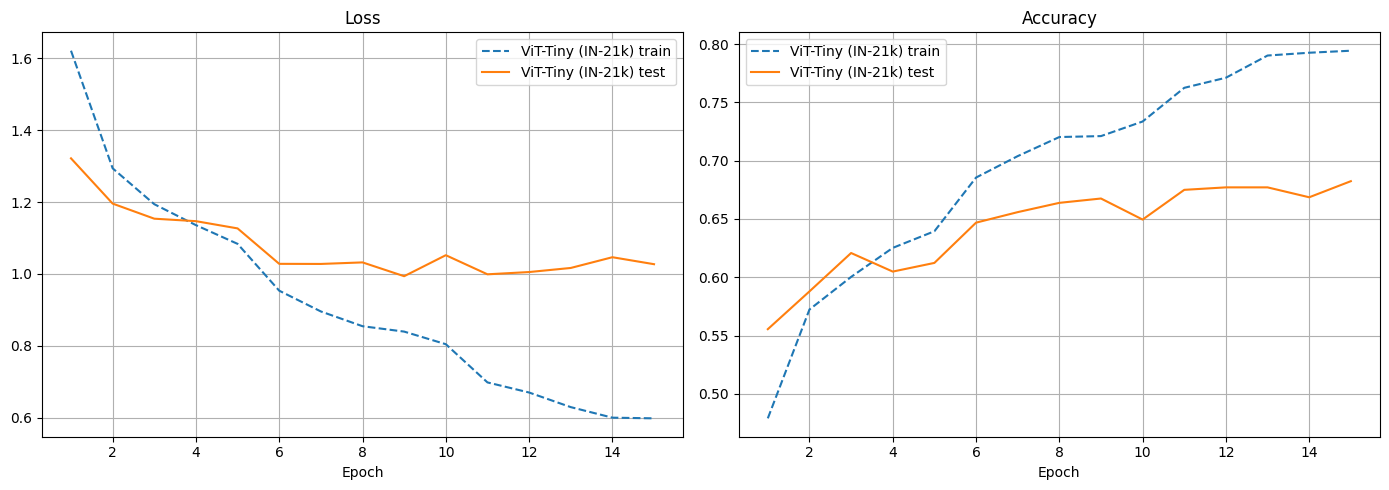

In [10]:
print('=== Обучение ViT-Tiny (ImageNet-21k) ===')
history_vit = train_model(vit, train_loader, test_loader, epochs=15, lr=1e-3)
plot_history([history_vit], ['ViT-Tiny (IN-21k)'])

In [11]:
print('=== Оценка ViT-Tiny ===')
f1_vit, _, _ = evaluate_f1(vit, test_loader, class_names)

=== Оценка ViT-Tiny ===
F1_macro: 0.6477

              precision    recall  f1-score   support

       Beige       0.71      0.65      0.68       120
       Black       0.52      0.58      0.55       160
        Blue       0.76      0.64      0.69       160
      Bronze       0.35      0.32      0.33        66
       Brown       0.54      0.59      0.57       160
        Gold       0.50      0.45      0.48        44
       Green       0.87      0.66      0.75       156
        Grey       0.49      0.53      0.51       160
 Multicolour       0.44      0.20      0.28        40
      Orange       0.82      0.79      0.81       112
        Pink       0.86      0.67      0.75        18
      Purple       0.63      0.71      0.67        73
         Red       0.85      0.86      0.85       160
      Silver       0.67      0.71      0.69       160
       White       0.75      0.91      0.82       160
      Yellow       0.91      0.98      0.94       134

    accuracy                          

---
## Модель 3: CNN с нуля

**Обоснование архитектуры:**

Задача классификации цвета проще, чем распознавание объектов - модели не нужно понимать форму или структуру, достаточно анализировать цветовые распределения. Поэтому:

1. **3 свёрточных блока** (Conv → BatchNorm → ReLU → MaxPool) - достаточно для извлечения цветовых и текстурных признаков. Больше слоёв приведут к переобучению на маленьком датасете.
2. **Увеличение числа фильтров** (32 → 64 → 128) - ранние слои ловят простые цветовые паттерны, поздние - их комбинации.
3. **Global Average Pooling** вместо Flatten - уменьшает число параметров, делает модель устойчивой к положению объекта в кадре.
4. **Dropout(0.5)** - агрессивная регуляризация, критична при обучении с нуля на малых данных.
5. **Малый FC слой (256)** - для цвета не нужно много признаков.

**Проблемы обучения с нуля:**
- Нет предобученных признаков → нужно больше данных и эпох
- Высокий риск переобучения → нужна сильная регуляризация и аугментации
- Случайная инициализация весов → нестабильное начало обучения

In [ ]:
class ColorCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

scratch_model = ColorCNN(num_classes).to(device)

total = sum(p.numel() for p in scratch_model.parameters())
print(f'ColorCNN: {total:,} параметров (все обучаемые)')
print(scratch_model)

ColorCNN: 130,832 параметров (все обучаемые)
ColorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2):

=== Обучение CNN с нуля ===
Epoch  1/25 | Train loss: 2.1327, acc: 0.2894 | Test  loss: 1.8401, acc: 0.3871
Epoch  5/25 | Train loss: 1.7461, acc: 0.4218 | Test  loss: 1.6787, acc: 0.4249
Epoch 10/25 | Train loss: 1.6388, acc: 0.4632 | Test  loss: 1.5204, acc: 0.4827
Epoch 15/25 | Train loss: 1.5834, acc: 0.4808 | Test  loss: 1.4394, acc: 0.5109
Epoch 20/25 | Train loss: 1.5518, acc: 0.4841 | Test  loss: 1.4244, acc: 0.5258
Epoch 25/25 | Train loss: 1.5319, acc: 0.4934 | Test  loss: 1.4013, acc: 0.5157


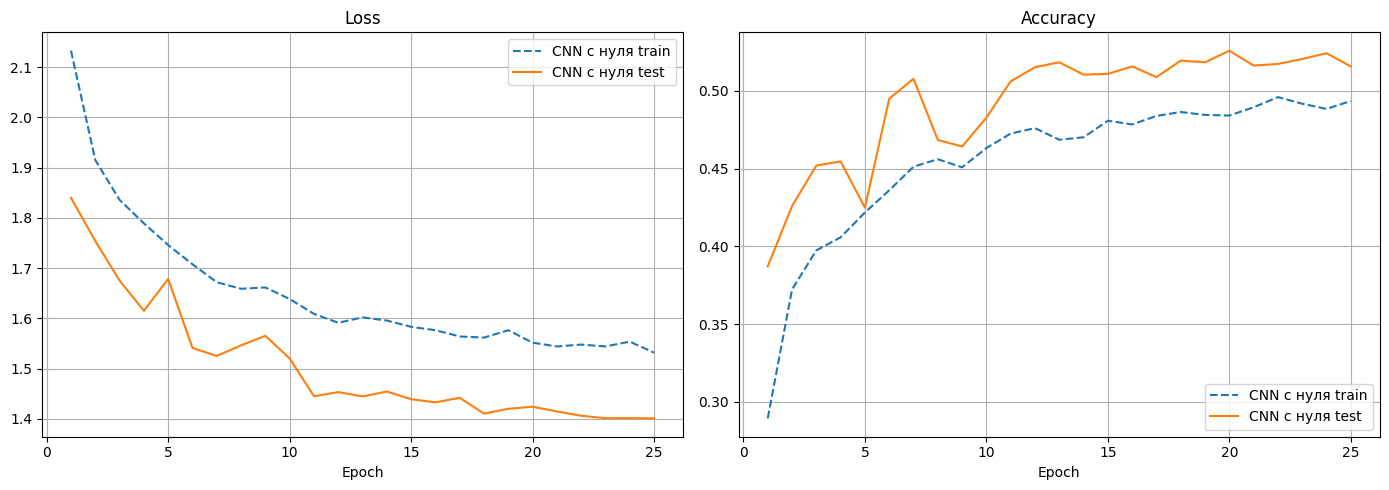

In [13]:
print('=== Обучение CNN с нуля ===')
history_scratch = train_model(scratch_model, train_loader, test_loader, epochs=25, lr=1e-3)
plot_history([history_scratch], ['CNN с нуля'])

In [14]:
print('=== Оценка CNN с нуля ===')
f1_scratch, labels_true, labels_pred = evaluate_f1(scratch_model, test_loader, class_names)

=== Оценка CNN с нуля ===
F1_macro: 0.4016

              precision    recall  f1-score   support

       Beige       0.39      0.45      0.42       120
       Black       0.32      0.64      0.43       160
        Blue       0.47      0.51      0.49       160
      Bronze       0.00      0.00      0.00        66
       Brown       0.33      0.47      0.39       160
        Gold       0.00      0.00      0.00        44
       Green       0.63      0.55      0.59       156
        Grey       0.30      0.17      0.22       160
 Multicolour       0.00      0.00      0.00        40
      Orange       0.67      0.65      0.66       112
        Pink       0.00      0.00      0.00        18
      Purple       0.43      0.34      0.38        73
         Red       0.70      0.88      0.78       160
      Silver       0.46      0.36      0.41       160
       White       0.67      0.78      0.72       160
      Yellow       0.95      0.94      0.94       134

    accuracy                        

C:\Users\valer\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\valer\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\valer\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

---
## Сравнение моделей

**Accuracy** считает долю правильных ответов по всем классам. Если 90% машин белые - модель, которая всегда говорит "белый", получит accuracy=90%, хотя она бесполезна.

**F1_macro** считает F1 для каждого класса отдельно и берёт среднее:
- F1 = 2 × (Precision × Recall) / (Precision + Recall)
- macro = среднее F1 по всем классам с одинаковым весом

Это даёт **честную оценку для несбалансированных данных** — модель должна хорошо работать на КАЖДОМ цвете, а не только на самом частом.

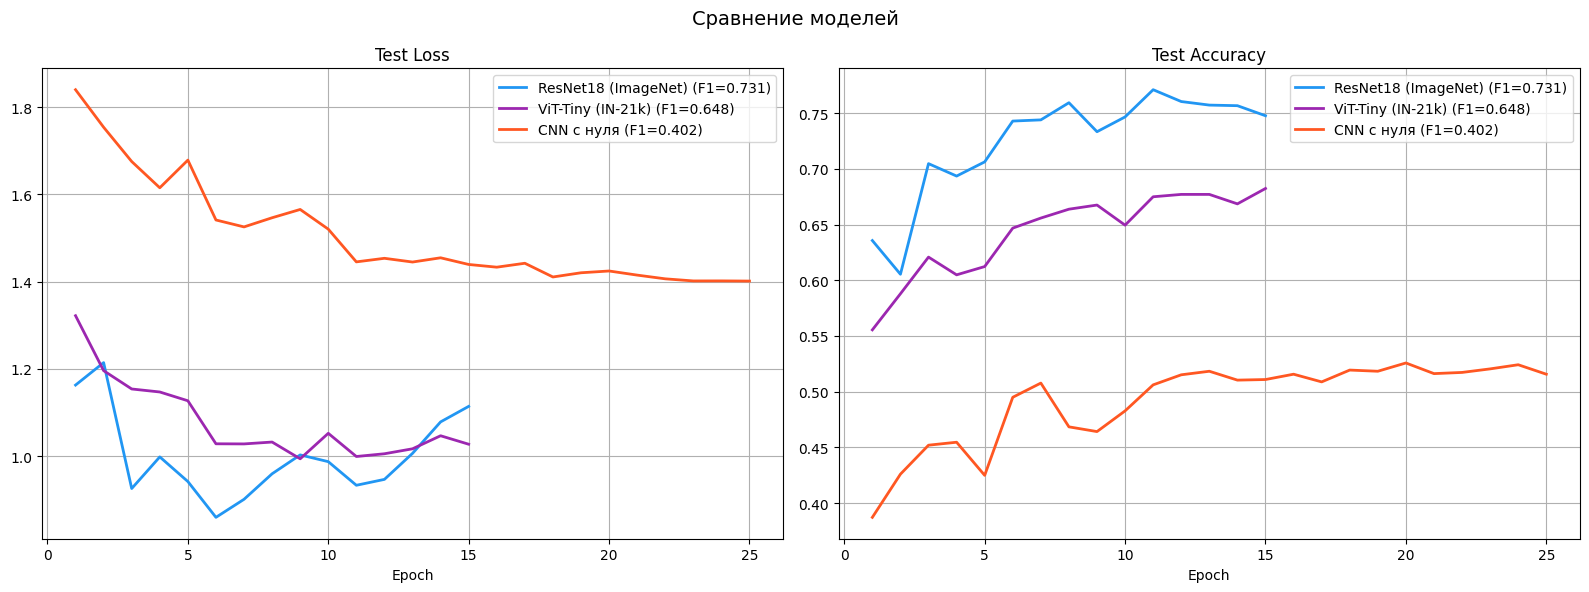


Модель                         | F1_macro
ResNet18 (ImageNet)            | 0.7306
ViT-Tiny (IN-21k)              | 0.6477
CNN с нуля                     | 0.4016


In [ ]:
results = {
    'ResNet18 (ImageNet)': (history_resnet, f1_resnet),
    'ViT-Tiny (IN-21k)': (history_vit, f1_vit),
    'CNN с нуля': (history_scratch, f1_scratch),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#2196F3', '#9C27B0', '#FF5722']

for (name, (h, f1)), c in zip(results.items(), colors):
    epochs = range(1, len(h['test_loss']) + 1)
    axes[0].plot(epochs, h['test_loss'], '-', label=f'{name} (F1={f1:.3f})', color=c, linewidth=2)
    axes[1].plot(epochs, h['test_acc'], '-', label=f'{name} (F1={f1:.3f})', color=c, linewidth=2)

axes[0].set_title('Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)
axes[1].set_title('Test Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)
plt.suptitle('Сравнение моделей', fontsize=14)
plt.tight_layout()
plt.show()

print('\n' + '='*50)
print(f'{"Модель":30s} | F1_macro')
print('='*50)
for name, (h, f1) in results.items():
    print(f'{name:30s} | {f1:.4f}')
print('='*50)

Лучшая модель: ResNet18 (ImageNet)
F1_macro: 0.7306

              precision    recall  f1-score   support

       Beige       0.81      0.68      0.74       120
       Black       0.68      0.59      0.64       160
        Blue       0.83      0.71      0.77       160
      Bronze       0.38      0.58      0.46        66
       Brown       0.60      0.62      0.61       160
        Gold       0.63      0.39      0.48        44
       Green       0.68      0.83      0.74       156
        Grey       0.62      0.63      0.63       160
 Multicolour       0.56      0.47      0.51        40
      Orange       0.87      0.82      0.84       112
        Pink       0.89      0.94      0.92        18
      Purple       0.82      0.85      0.83        73
         Red       0.89      0.94      0.92       160
      Silver       0.75      0.82      0.79       160
       White       0.91      0.84      0.87       160
      Yellow       0.96      0.95      0.95       134

    accuracy               

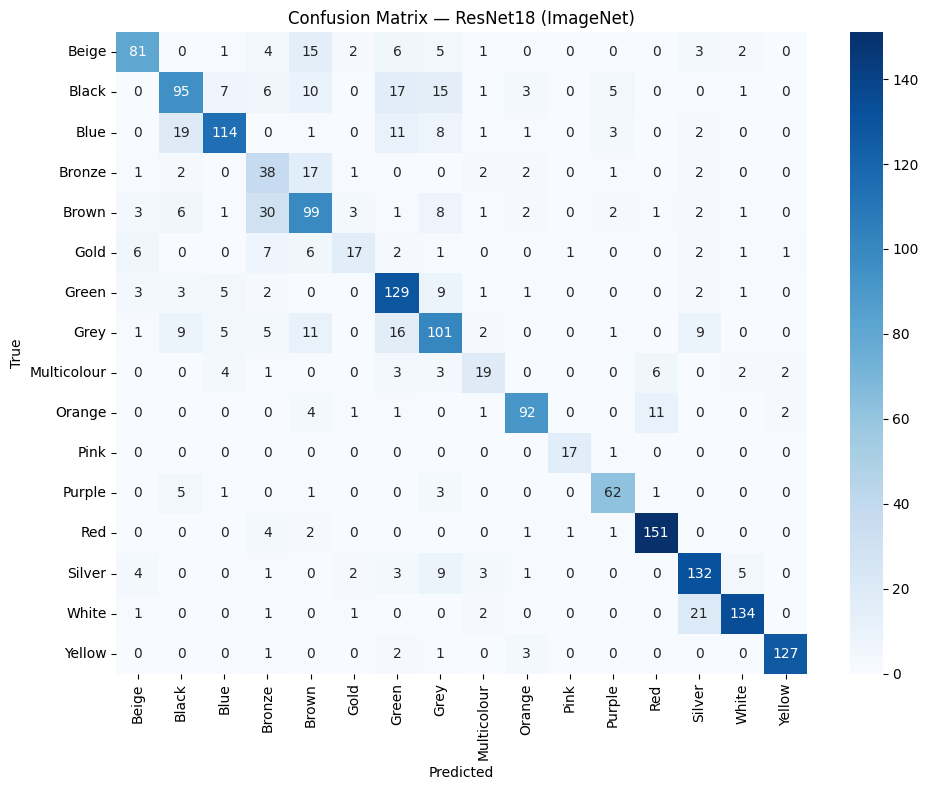

In [ ]:
best_name = max(results, key=lambda k: results[k][1])
print(f'Лучшая модель: {best_name}')

if 'ResNet' in best_name:
    best_model = resnet
elif 'ViT' in best_name:
    best_model = vit
else:
    best_model = scratch_model

_, y_true, y_pred = evaluate_f1(best_model, test_loader, class_names)

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

---
## Выводы

**Результаты:**

| Модель | F1_macro | Accuracy |
|---|---|---|
| **ResNet18 (ImageNet)** | **0.7306** | 75% |
| ViT-Tiny (ImageNet-21k) | 0.6477 | 68% |
| CNN с нуля | 0.4016 | 52% |

**1. ResNet18 (ImageNet)** - лучший результат (F1=0.73). Предобученные на ImageNet свёрточные фильтры уже умеют выделять цветовые и текстурные признаки. Fine-tuning последнего блока + FC быстро адаптирует модель под новую задачу.

**2. ViT-Tiny (ImageNet-21k)** - слабее ResNet (F1=0.65), несмотря на предобучение на более широком наборе (21k классов, 14M изображений). Причины: Transformer-архитектура требует значительно больше данных для раскрытия потенциала (~7.5k train - мало для ViT); заморожено большинство блоков (10 из 12), что ограничивает адаптацию.

**3. CNN с нуля** - худший результат (F1=0.40). Четыре класса (Bronze, Gold, Multicolour, Pink) получили F1=0.00 - модель вообще не научилась их распознавать. Без предобученных признаков 130k параметров и 7.5k изображений недостаточно для 16 классов.

**Вывод по F1_macro:**
- Accuracy (75% у лучшей модели) завышает оценку, потому что доминирующие классы (Black, White, Red - по 640 train) вносят непропорционально большой вклад.
- F1_macro (0.73) даёт честную картину: модель хорошо справляется с частыми и чистыми цветами (Red, Yellow, White), но путает похожие (Grey-Silver, Brown-Bronze-Gold, Beige-White).
- Confusion matrix подтверждает: основные ошибки - между визуально близкими цветами.

**Общий вывод:** Transfer Learning с предобученной на ImageNet моделью значительно превосходит обучение с нуля. Архитектура CNN (ResNet) лучше подходит для данной задачи при ограниченном объёме данных, чем Transformer (ViT).